In [1]:
import xarray as xr, regionmask, matplotlib, matplotlib.pyplot as plt, geopandas as gpd, cartopy, pandas as pd
xr.set_options(keep_attrs = True)
matplotlib.rcParams['savefig.bbox'] = "tight"

from IPython.display import clear_output

ERROR 1: PROJ: proj_create_from_database: Open of /rds/general/user/cb2714/home/miniforge3/envs/wwa/share/proj failed


In [2]:
class MidpointNormalise(matplotlib.colors.Normalize):
    """ From: https://matplotlib.org/users/colormapnorms.html"""
    def __init__(self, vmin=None, vmax=None, midpoint=0, clip=False):
        self.midpoint = midpoint
        matplotlib.colors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # I'm ignoring masked values and all kinds of edge cases to make a
        # simple example...

        result, is_scalar = self.process_value(value)
        self.autoscale_None(result)

        vlargest = max( abs( self.vmax - self.midpoint ), abs( self.vmin - self.midpoint ) )
        x, y = [ self.midpoint - vlargest, self.midpoint, self.midpoint + vlargest], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))

# Download data 

## GMST

In [ ]:
# ! wget https://climexp.knmi.nl/data/igiss_al_gl_a_4yrlo.dat -O data/gmst.txt

In [1]:
! wget https://object-store.os-api.cci2.ecmwf.int/cci2-prod-cache-2/2026-05-27/cacc706cf043cc2c1f0dad5debf5d390.nc -O data/era5-land_2026-05_dl260527.nc

--2026-05-27 11:36:17--  https://object-store.os-api.cci2.ecmwf.int/cci2-prod-cache-2/2026-05-27/cacc706cf043cc2c1f0dad5debf5d390.nc
Resolving object-store.os-api.cci2.ecmwf.int (object-store.os-api.cci2.ecmwf.int)... 2a0c:5bc0:4c:ff::889c:8803, 136.156.136.3
Connecting to object-store.os-api.cci2.ecmwf.int (object-store.os-api.cci2.ecmwf.int)|2a0c:5bc0:4c:ff::889c:8803|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30222430 (29M) [application/netcdf]
Saving to: ‘data/era5-land_2026-05_dl260527.nc’

data/era5-land_2026 100%[===================>]  28.82M  54.0MB/s    in 0.5s    

2026-05-27 11:36:18 (54.0 MB/s) - ‘data/era5-land_2026-05_dl260527.nc’ saved [30222430/30222430]



## ERA5-Land

### Download from Copernicus

In [ ]:
xn,xx,yn,yx = [34,56,16,33]

import cdsapi, os
from IPython.display import clear_output

client = cdsapi.Client()
dataset = "derived-era5-land-daily-statistics"

for y in range(2025,1949,-1):
    y = str(y)

    for m in [5]:
        m = str(m).rjust(2,"0")

        print(y+m)

        new_fnm = "/rds/general/user/cb2714/home/99_ephemera/hajj/tasmax-daily_era5-land_"+"_".join([str(x) for x in [xn,xx,yn,yx]])+"_"+y+m+".nc"
        if os.path.exists(new_fnm): continue

        request = {
            "variable": ["2m_temperature"],
            "year": y,
            "month": m,
            "day": [
                "01", "02", "03",
                "04", "05", "06",
                "07", "08", "09",
                "10", "11", "12",
                "13", "14", "15",
                "16", "17", "18",
                "19", "20", "21",
                "22", "23", "24",
                "25", "26", "27",
                "28", "29", "30",
                "31"
            ],
            "daily_statistic": ["daily_maximum"],
            "time_zone": "utc+00:00",
            "frequency": "1_hourly",
            "area": [yx,xn,yn,xx],
            "data_format": "netcdf"
        }
        client.retrieve(dataset, request, new_fnm)

    clear_output(wait = False)
print("Done.")

200305


2026-05-27 14:01:58,614 INFO Request ID is d1c010ec-ec08-4d90-b083-8d17cd134634
2026-05-27 14:01:58,806 INFO status has been updated to accepted
2026-05-27 14:02:32,418 INFO status has been updated to running


### Compile into single file 

In [ ]:
! module load CDO/2.4.4-gompi-2024a; cdo mergetime /rds/general/user/cb2714/home/99_ephemera/hajj/*.nc data/tas-daily_era5-land_-11_35_33_66_mjja_1950-2025.nc
clear_output(wait = False)

## Extract time series

In [ ]:
da = xr.open_dataset("data/tas-daily_era5-land_-11_35_33_66_mjja_1950-2025.nc").t2m - 273.15

In [ ]:
sf = gpd.read_file("sf_adm1")
sf_m = sf.iloc[[10]].explode()
sf_m = sf_m.loc[[a == sf_m.geometry.area.max() for a in sf_m.geometry.area]]

In [ ]:
rm_mp = regionmask.mask_geopandas(sf_m, da.longitude, da.latitude)

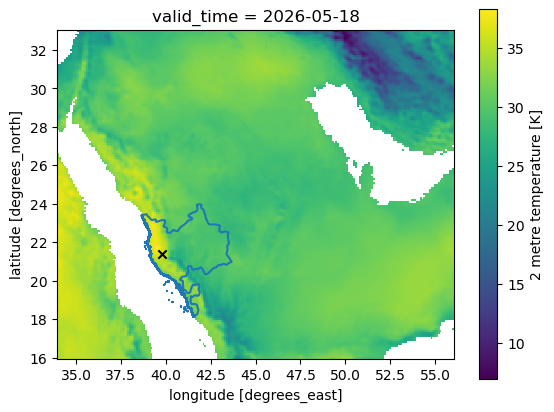

In [35]:
da.isel(valid_time = -1).plot()
sf.iloc[[10]].boundary.plot(ax = plt.gca())
plt.gca().scatter(39.8,21.4, color = "k", marker = "x")

## Fit gridded trend

In [69]:
gmst = pd.read_table("gmst.txt", sep = " +", comment = "#", engine = "python", header = None, names = ["year", "gmst"], index_col = "year").loc[slice("1950","2025")]

In [ ]:
da_m = da.sel(valid_time = slice(None, "2025")).resample(valid_time = "MS").mean()

In [76]:
coeffs = {m : da_m.groupby("valid_time.month")[m].assign_coords(valid_time = gmst.gmst.values).polyfit("valid_time", deg = 1).polyfit_coefficients for m in [5,6,7,8]}

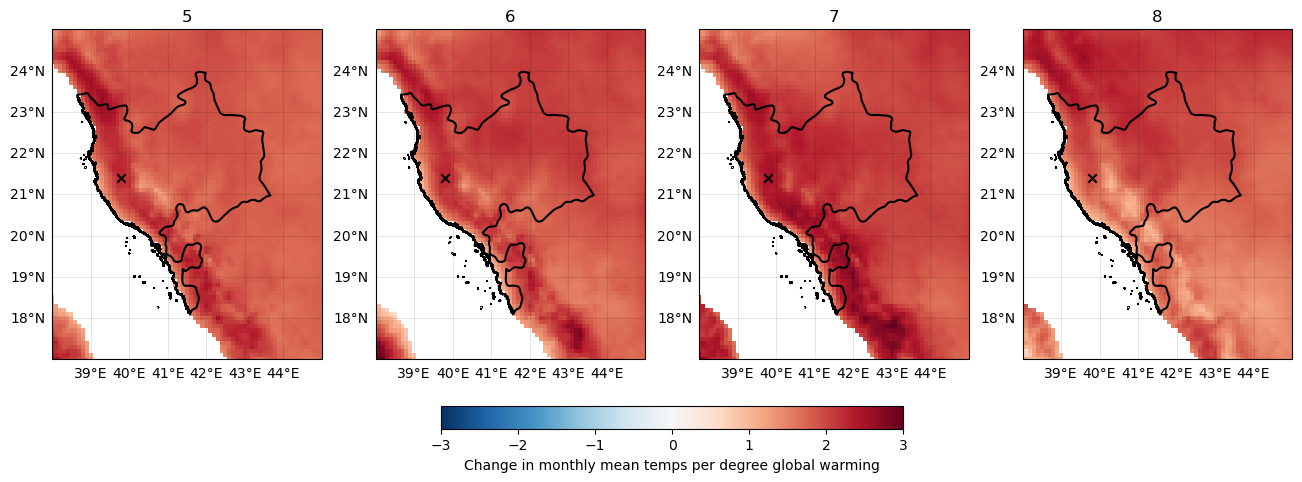

In [102]:
nc = 4
fig, axs = plt.subplots(ncols = 4, subplot_kw = {"projection" : cartopy.crs.PlateCarree(), "extent" : [38,45,17,25]}, figsize = (nc*4,6), dpi = 100)

plot_kw = {"vmin" : -3, "vmax" : 3, "cmap" : "RdBu_r", "add_colorbar" : False}

for i in range(4):
    ax = axs[i]
    m = [5,6,7,8][i]
    cbar = coeffs[m].sel(degree = 1).plot(ax = ax, **plot_kw)

    sf.iloc[[10]].boundary.plot(ax = ax, color = "k")
    ax.scatter(39.8,21.4, color = "k", marker = "x")
    ax.gridlines(draw_labels = ["bottom", "left"], color = "k", alpha = 0.1)
    ax.set_title(m)

plt.colorbar(cbar, ax = axs, location = "bottom", fraction = 0.05, pad = 0.1, label = "Change in monthly mean temps per degree global warming")

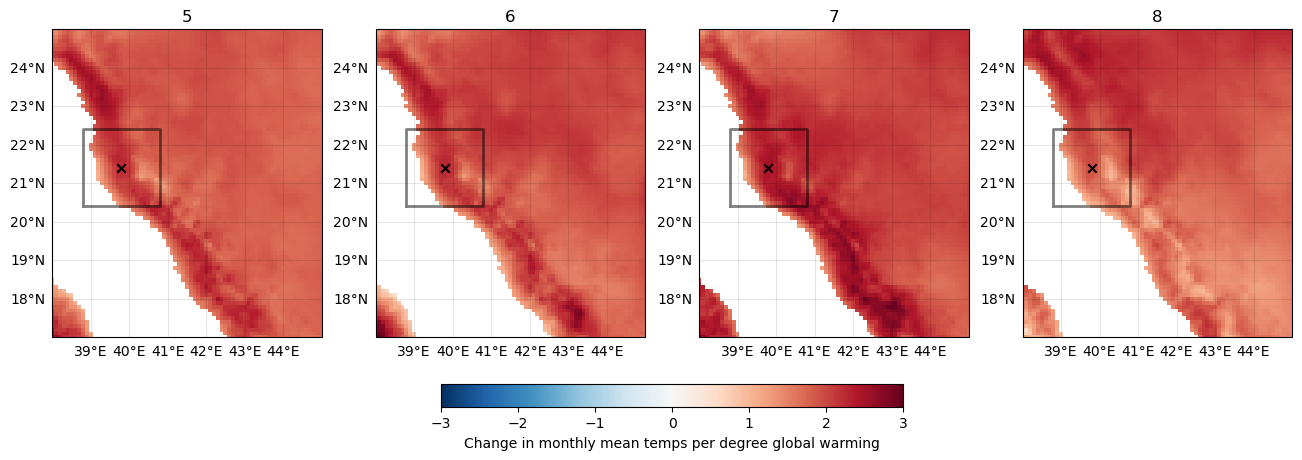

In [107]:
x0 = 39.8; y0 = 21.4; k = 1

nc = 4
fig, axs = plt.subplots(ncols = 4, subplot_kw = {"projection" : cartopy.crs.PlateCarree(), "extent" : [38,45,17,25]}, figsize = (nc*4,6), dpi = 100)

plot_kw = {"vmin" : -3, "vmax" : 3, "cmap" : "RdBu_r", "add_colorbar" : False}

for i in range(4):
    ax = axs[i]
    m = [5,6,7,8][i]
    cbar = coeffs[m].sel(degree = 1).plot(ax = ax, **plot_kw)

    # sf.iloc[[10]].boundary.plot(ax = ax, color = "k")
    ax.plot([x0-k,x0-k,x0+k,x0+k,x0-k], [y0-k,y0+k,y0+k,y0-k,y0-k], color = "k", lw = 2, alpha = 0.5)
    ax.scatter(x0,y0, color = "k", marker = "x")
    ax.gridlines(draw_labels = ["bottom", "left"], color = "k", alpha = 0.1)
    ax.set_title(m)

plt.colorbar(cbar, ax = axs, location = "bottom", fraction = 0.05, pad = 0.1, label = "Change in monthly mean temps per degree global warming")

In [133]:
ts =  da.sel(longitude = slice(x0-k, x0+k), latitude = slice(y0+k, y0-k)).mean(["latitude", "longitude"])

In [141]:
for m in [5,6,7,8]:
    ts_m = ts.resample(valid_time = "MS").mean().groupby("valid_time.month")[m]
    ts_m = ts_m.assign_coords(valid_time = ts_m.valid_time.dt.year).rename(valid_time = "year").to_dataframe()
    ts_m.to_csv("ts/t2m-mean_"+str(m)+"_era5-land_box.csv")

    ts_x = ts.resample(valid_time = "MS").max().groupby("valid_time.month")[m]
    ts_x = ts_x.assign_coords(valid_time = ts_x.valid_time.dt.year).rename(valid_time = "year").to_dataframe()
    ts_x.to_csv("ts/tx1x_"+str(m)+"_era5-land_box.csv")